## Abstract ##

El rendimiento academico es un factor clave dentro del ambito educativo, ya que puede verse afectado por multiples variables personales, familiares y socioeconómicas. Comprender estos factores resulta fundamental para identificar patrones de desempeño y mejorar la toma de decisiones en instituciones educativas.

Este proyecto analiza datos de estudiantes mediante tecnicas de analisis de datos y Machine Learning con el fin de estudiar los factores que influyen en las notas finales y construir modelos predictivos del rendimiento academico.

La audiencia objetivo incluye docentes, instituciones educativas y profesionales interesados en aplicar herramientas analíticas para comprender y anticipar el desempeño estudiantil.

## Contexto Comercial y Analitico

El rendimiento academico representa un problema importante para las instituciones educativas, ya que son muchos los factores que pueden afectar el desempeño de los estudiantes.

Contar con herramientas predictivas permite identificar patrones de comportamiento y comprender qué variables poseen mayor influencia sobre las notas finales.

Este proyecto utiliza tecnicas de Machine Learning para construir modelos capaces de predecir el rendimiento académico y generar insights utiles para la toma de decisiones educativas.

## Preguntas/Hipótesis a Resolver mediante el Análisis de Datos ##

- ¿Qué variables poseen mayor influencia sobre el rendimiento academico de los estudiantes?
- ¿Los factores socioeconomicos impactan significativamente en las notas finales?
- ¿Existe relacion entre el involucramiento parental y el desempeño academico?
- ¿Las horas de estudio presentan relacion con el rendimiento academico?
- ¿Es posible predecir el rendimiento academico mediante modelos de Machine Learning?
- ¿Qué modelo presenta mejor capacidad predictiva?

## Objetivo

El objetivo principal del proyecto es desarrollar y comparar distintos modelos de Machine Learning capaces de predecir el rendimiento académico de los estudiantes.

Para ello, se realizará un proceso de limpieza, transformacion y preprocesamiento de datos, incluyendo encoding y preparacion de variables para modelado predictivo. Posteriormente, se evaluara el rendimiento de distintos modelos mediante metricas estadisticas y tecnicas de optimizacion de hiperparametros, con el fin de seleccionar el modelo con mejor desempeño.

##Presentacion Ejecutiva

https://canva.link/t63gh1u35vyxwn4

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

url = "https://raw.githubusercontent.com/Buja2244/DS2_Preentrega_1/main/Students_Performance.csv"

df = pd.read_csv(url)

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [13]:
#Forma
print("Shape:", df.shape)

Shape: (6607, 20)


In [14]:
#Info
print("\nInfo:")
df.info()


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null

In [15]:
#Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)


Tipos de datos:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object


In [16]:
#Nulos
print("\nValores nulos:")
print(df.isnull().sum())


Valores nulos:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


## Descripcion de variables
Variable objetivo:
- Exam_Score: nota final obtenida por el estudiante en el examen final.

Variables numericas:
- Hours_Studied: cantidad de horas de estudio.
- Attendance: porcentaje de asistencia a clases.
- Sleep_Hours: cantidad promedio de horas de sueño.
- Previous_Scores: rendimiento academico previo del estudiante.
- Tutoring_Sessions: cantidad de sesiones de tutoria recibidas.
- Physical_Activity: nivel de actividad física del estudiante.

Variables categoricas:
- Parental_Involvement: nivel de participacion de los padres en la educacion.
- Access_to_Resources: nivel de acceso a recursos educativos.
- Motivation_Level: nivel de motivacion academica.
- Family_Income: nivel de ingresos familiares.
- Teacher_Quality: percepcion de calidad docente.
- School_Type: tipo de institucion educativa.
- Gender: genero del estudiante.

## Data Wrangling


In [17]:
#Valores duplicados
df.duplicated().sum()

np.int64(0)

No se encontraron valores duplicados.

In [18]:
#Nulos por columna
(df.isnull().sum() / len(df)) * 100

,0
Hours_Studied,0.000000
Attendance,0.000000
Parental_Involvement,0.000000
Access_to_Resources,0.000000
Extracurricular_Activities,0.000000
Sleep_Hours,0.000000
Previous_Scores,0.000000
Motivation_Level,0.000000
Internet_Access,0.000000
Tutoring_Sessions,0.000000


In [19]:
#Los nulos representan apenas el 1% de los valores asi que eliminarlos no deberia afectar el dataset en gran medida
df_clean = df.dropna()

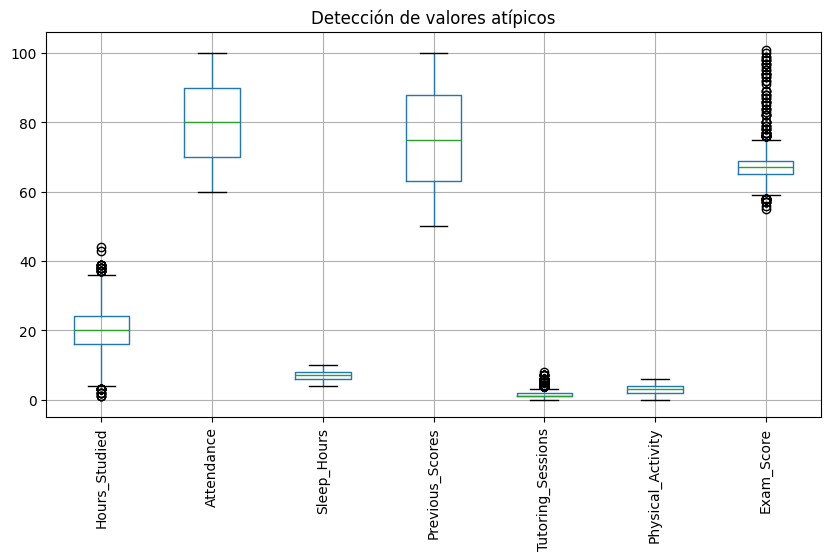

In [20]:
#Outliers
plt.figure(figsize=(10,5))
df_clean.boxplot()
plt.xticks(rotation=90)
plt.title("Detección de valores atípicos")
plt.show()

Luego de analizar posibles valores atipicos mediante boxplots, si bien se observaron algunos valores fuera del rango, estos no parecen extremos ni inconsistentes con el contexto del problema. Se decidio conservarlos para no perder informacion potencialmente relevante.

##EDA

Analisis Univariado


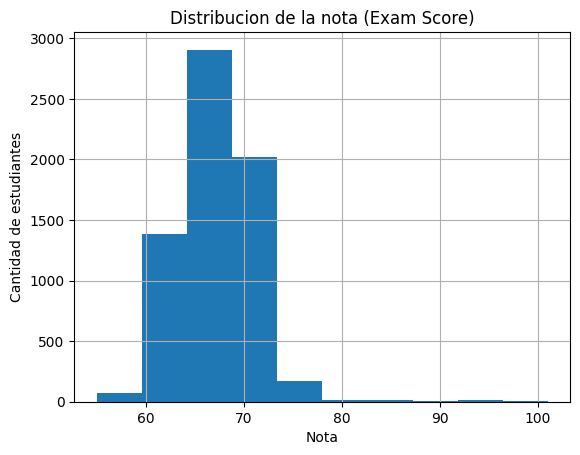

In [21]:
#Distribucion de la Variable Objetivo
plt.figure()
df["Exam_Score"].hist()
plt.title("Distribucion de la nota (Exam Score)")
plt.xlabel("Nota")
plt.ylabel("Cantidad de estudiantes")
plt.show()

La distribución de la variable objetivo (Exam Score) presenta una forma normal, con una mayor concentracion de estudiantes en valores intermedios y una menor concentracion en los extremos.

Analisis Bivariado

<Figure size 640x480 with 0 Axes>

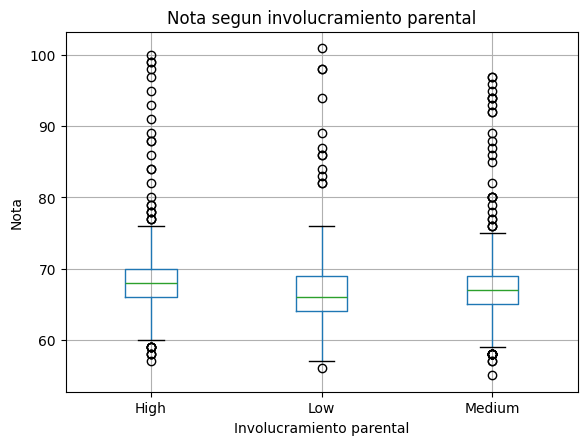

In [22]:
#Analisis bivariado Score-Parents
plt.figure()
df.boxplot(column="Exam_Score", by="Parental_Involvement")
plt.title("Nota segun involucramiento parental")
plt.suptitle("")
plt.xlabel("Involucramiento parental")
plt.ylabel("Nota")
plt.show()

Se observa que los estudiantes con mayor nivel de involucramiento parental presentan mejores resultados.

<Figure size 640x480 with 0 Axes>

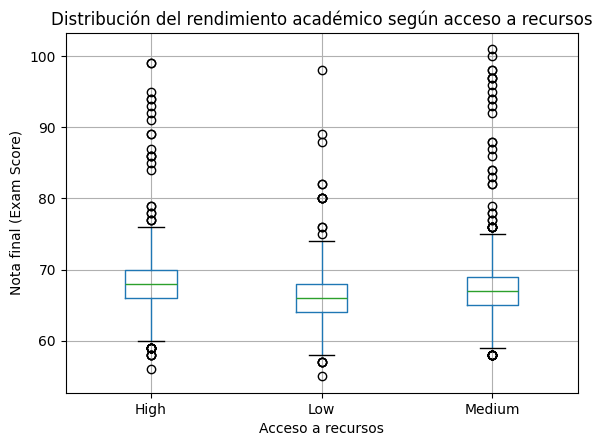

In [23]:
#Analisis bivariado Score-Resources
plt.figure()
df.boxplot(column="Exam_Score", by="Access_to_Resources")
plt.title("Distribución del rendimiento académico según acceso a recursos")
plt.suptitle("")
plt.xlabel("Acceso a recursos")
plt.ylabel("Nota final (Exam Score)")
plt.show()

Se observa que los estudiantes con mayor acceso a recursos presentan un mejor rendimiento academico un patron similar al observado en el involucramiento parental.

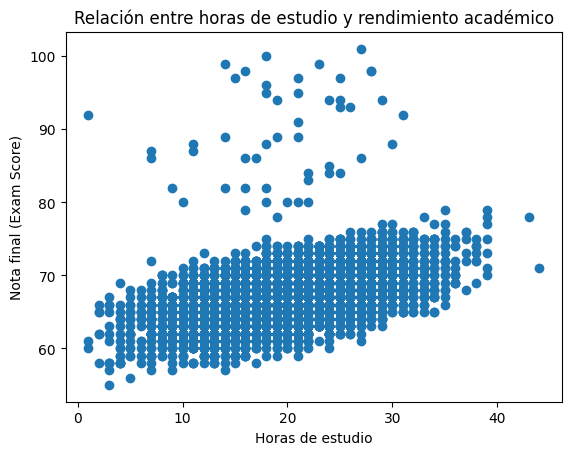

In [24]:
#Analisis bivariado Hours-Score
plt.figure()
plt.scatter(df["Hours_Studied"], df["Exam_Score"])
plt.title("Relación entre horas de estudio y rendimiento académico")
plt.xlabel("Horas de estudio")
plt.ylabel("Nota final (Exam Score)")
plt.show()

Se encuentraa una relacion positiva entre la cantidad de horas de estudio y el rendimiento. Pero la dispersion indica que estudiar más generalmente se asocia con mejores resultados pero existen otros factores que tambien influyen significativamente en el desempeño.

In [25]:
#Analisis Previous_Scores-Exam_Score
df["Previous_Scores"].corr(df["Exam_Score"])

np.float64(0.17507908702291106)

La correlación entre el rendimiento previo y la nota final es baja, lo que indica una relacion debil entre ambas variables. Esto sugiere que el desempeño anterior no es un predictor fuerte del rendimiento actual.

Analisis Multivariado

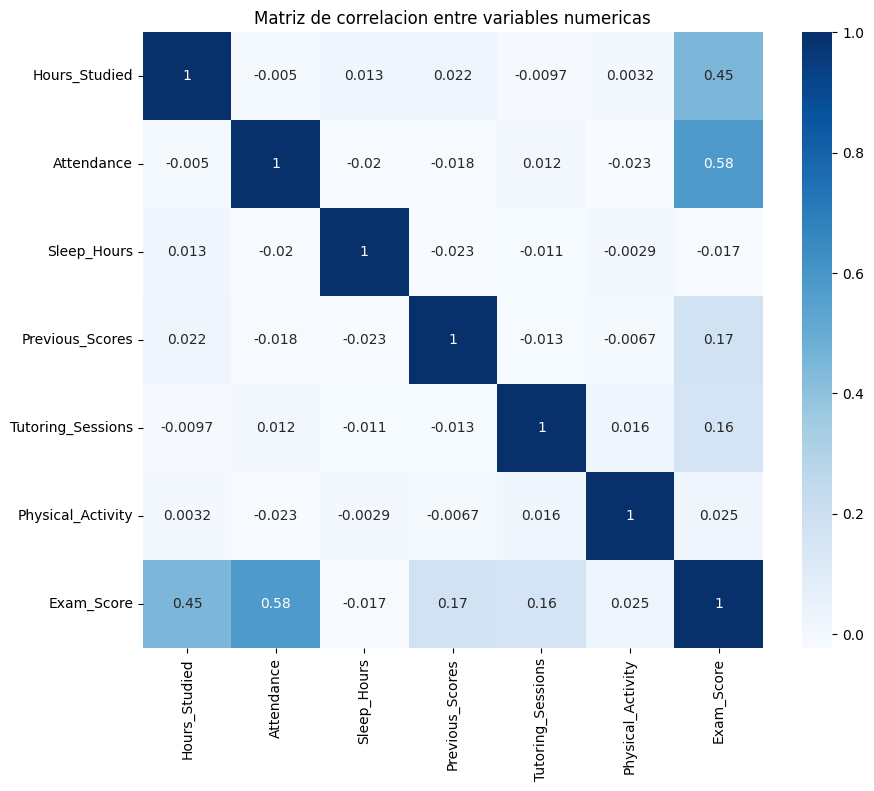

In [26]:
#Matriz de Correlacion
plt.figure(figsize=(10,8))
corr = df_clean.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Matriz de correlacion entre variables numericas")
plt.show()

Attendance (0.58): Es la variable con mayor correlacion positiva con la nota,indica que asistir a clases tiene un impacto importante en el desempeño.

Hours_Studied (0.45): También muestra una correlacion moderada. Estudiar mas horas esta asociado con mejores resultados.

Previous_Scores (0.17) y Tutoring_Sessions (0.16): Tienen correlaciones debiles.

Sleep_Hours (-0.017) y Physical_Activity (0.025): Prácticamente no tienen correlación con la nota.

**El rendimiento esta principalmente explicado por asistencia y horas de estudio.**

##Feature Engineering
No fue necesario realizar creacion de nuevas variables, ya que el dataset original contenia variables suficientemente descriptivas y relevantes para el problema planteado, ademas tampoco contaba con fechas ni variables complejas para combinar.


##Feature Selection

In [27]:
#Objetivo
#Objetivo
y = df_clean["Exam_Score"]

#Predictora
X = df_clean.drop("Exam_Score", axis=1)

Se selecciono como variable objetivo a Exam_Score, correspondiente a la nota final de los estudiantes.

In [28]:
# One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

Las variables categoricas fueron transformadas mediante One-Hot encoding para permitir su utilizacion en modelos de Machine Learning.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

Utilizamos train/test split para dividir los datos en dos partes

In [30]:
#Estandarizacion
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Se aplico  StandardScaler sobre las variables predictoras, para normalizar la escala de los datos y mejorar el rendimiento de modelos.

##Regresion Lineal

In [31]:
#RegresionL
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 4.173262062207914
R2: 0.7314386522127073


El modelo obtuvo un MSE de 4.17 lo que indica que en promedio las predicciones presentan una desviacion baja respecto a los valores reales.

El coeficiente de determinación R² es de 0.73, lo que significa que el modelo logra explicar aproximadamente el 73% de la variabilidad en el rendimiento academico.

Se analizan los coeficientes de la regresión lineal

In [32]:
#Validacion Cruzada
cv_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("Validacion Cruzazda RL R2:", cv_scores.mean())

Validacion Cruzazda RL R2: 0.7205001931960485


El modelo de regresion lineal presenta un rendimiento consistente y estable, con prácticamente la misma capacidad predictiva en validación cruzada que en el conjunto original.

In [33]:
#Coeficientes
coef = pd.Series(model.coef_, index=X_encoded.columns)

#Sort
coef_sorted = coef.sort_values(key=abs, ascending=False)
coef_sorted.head(10)

,0
Attendance,2.296176
Hours_Studied,1.775942
Access_to_Resources_Low,-0.821512
Parental_Involvement_Low,-0.804226
Previous_Scores,0.699932
Tutoring_Sessions,0.594588
Family_Income_Low,-0.562576
Parental_Involvement_Medium,-0.519036
Access_to_Resources_Medium,-0.505405
Motivation_Level_Low,-0.505161


A partir del análisis de los coeficientes del modelo, se observa que las variables con mayor impacto negativo en el rendimiento academico estan asociadas a factores socioeconómicos y contextuales, como el bajo acceso a recursos, el bajo involucramiento parental y el bajo nivel de ingresos familiares.

##Random Forest

In [34]:
#Segundo modelo - Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MSE:", mse_rf)
print("Random Forest R2:", r2_rf)

Random Forest MSE: 6.046076489028213
Random Forest R2: 0.6109176882461537


El modelo obtuvo un MSE de 6.04 lo que indica que en promedio las predicciones presentan una desviacion baja respecto a los valores reales.

El coeficiente de determinación R² es de 0.61, lo que significa que el modelo logra explicar aproximadamente el 61% de la variabilidad en el rendimiento academico.

In [35]:
#Validacion Cruzada
cv_scores_rf = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Validacion Cruzazda RF R2:", cv_scores_rf.mean())

Validacion Cruzazda RF R2: 0.5946180573586602


La validacion cruzada confirmo que el modelo de regresion lineal presenta una mejor capacidad de generalizacion en comparacion con Random Forest. Esto indica que las relaciones presentes en el dataset son principalmente lineales.

Se analizan los coeficientes de Random Forest


In [36]:
#Importancia de variables en Random Forest
importance = pd.Series(
    rf_model.feature_importances_,
    index=X_encoded.columns
)

importance_sorted = importance.sort_values(ascending=False)
importance_sorted.head(10)

,0
Attendance,0.382529
Hours_Studied,0.244132
Previous_Scores,0.087748
Tutoring_Sessions,0.037831
Sleep_Hours,0.027002
Physical_Activity,0.026572
Parental_Involvement_Low,0.021636
Access_to_Resources_Low,0.018697
Learning_Disabilities_Yes,0.012329
Access_to_Resources_Medium,0.011344


Tambien se analizaron las variables más importantes segun Random Forest, utilizando feature importance.

Las variables relevantes obtenidas por Random Forest coinciden en gran medida con las obtenidas mediante Regresion Lineal.

## Comparacion de Modelos

### Regresión Lineal
- MSE: 4.173
- R²: 0.731
- Validacion Cruzazda RL R2: 0.720

### Random Forest
- MSE: 6.046
- R²: 0.611
- Validacion Cruzazda RF R2: 0.594

El modelo de Regresión Lineal presenta mejor desempeño al obtener un menor error y un mayor coeficiente de determinacion.

##Optimizacion de modelos

In [37]:
#Regresion Lineal
param_grid_ridge = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}
grid_ridge = GridSearchCV(
    Ridge(),
    param_grid_ridge,
    cv=5,
    scoring="r2"
)
grid_ridge.fit(X_train_scaled, y_train)
best_ridge = grid_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_scaled)
ridge_r2 = r2_score(y_test, y_pred_ridge)
print("Mejor alpha:", grid_ridge.best_params_)
print("R2 Optimizado:", ridge_r2)

Mejor alpha: {'alpha': 10}
R2 Optimizado: 0.7314725513221405


Se aplicó Ridge Regression junto a GridSearchCV para optimizar el modelo, intentando mejorar la capacidad de generalizacion y reducir posibles problemas de sobreajuste.
La optimizacion produjo resultados similares a la Regresion Lineal original, indicando que el modelo inicial ya presentaba un buen nivel de generalización y estabilidad.

In [38]:
#Random Forest
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
best_r2 = r2_score(y_test, y_pred_best)

print("Mejores Parametros:", grid_search.best_params_)
print("R2 Optimizado:", best_r2)

Mejores Parametros: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
R2 Optimizado: 0.6211727111181369


Se utilizó GridSearchCV para probar distintas combinaciones de hiperparámetros de manera automática y encontrar la configuración que produce el mejor rendimiento del modelo.

En el caso de Random Forest se observo una pequeña mejora en el rendimiento.


## Conclusiones Finales
El proyecto permitio analizar distintos factores relacionados con el rendimiento academico de los estudiantes mediante tecnicas de analisis de datos y Machine Learning.

A través del analisis exploratorio se identifico que variables como el involucramiento parental, el acceso a recursos educativos, las horas de estudio y el nivel socioeconómico presentan una relación significativa con la nota final.

Se implementaron distintos modelos predictivos, destacándose la Regresion Lineal como el modelo con mejor desempeño y capacidad de generalizacion, alcanzando los mejores valores de R² y menor error de prediccion.

Finalmente, los resultados obtenidos demuestran que el rendimiento académico puede ser modelado de manera efectiva utilizando variables academicas, personales y socioeconomicas, permitiendo comprender mejor los factores que influyen en el desempeño estudiantil.